# 95. ONNX CPU推論の速度・品質評価

## 目的
NB94で結果が良かった2モデルについて、ONNX形式でのCPU推論を評価する。

## 評価対象モデル
| # | モデル | HF ID | パラメータ | Emb次元 |
|---|--------|--------|-----------|--------|
| 1 | EmbeddingGemma-300M | google/embeddinggemma-300m | 308M | 768 |
| 2 | Qwen3-Embedding-0.6B | Qwen/Qwen3-Embedding-0.6B | 600M | 1024 |

## 評価項目
1. **ONNX変換**: optimumを使ったONNXエクスポート
2. **速度比較**: GPU (PyTorch) vs CPU (PyTorch) vs CPU (ONNX Runtime) の推論速度
3. **ベクトル同一性**: GPU PyTorch出力とONNX CPU出力のコサイン類似度・最大絶対誤差

## 参考
- NB65: CPU性能比較（E5-base, GTE-Small等のST vs FastEmbed比較）
- NB91: 軽量Embeddingモデル性能比較（GPU速度測定）
- NB94: ネイティブバイナリ vs ITQ-LSH比較（モデル選定根拠）

## 0. セットアップ

In [1]:
import numpy as np
import time
import gc
import torch
import pandas as pd
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path("../data")
ONNX_DIR = DATA_DIR / "onnx_models"
ONNX_DIR.mkdir(exist_ok=True)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CPU threads: {torch.get_num_threads()}")

import onnxruntime as ort
print(f"ONNX Runtime: {ort.__version__}")
print(f"ONNX Runtime providers: {ort.get_available_providers()}")

PyTorch: 2.10.0+cu128, CUDA: True
GPU: NVIDIA GeForce RTX 4090
CPU threads: 6
ONNX Runtime: 1.23.2
ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']


2026-03-07 18:31:18.183335552 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. データ準備

In [2]:
from datasets import load_dataset

N_SAMPLES = 1000
MAX_CHARS = 500

def collect_wikipedia(lang_code: str, n_samples: int = N_SAMPLES) -> list[str]:
    """Wikipediaからテキストを収集"""
    wiki = load_dataset(
        "wikimedia/wikipedia", f"20231101.{lang_code}",
        split="train", streaming=True
    )
    documents = []
    for i, item in enumerate(tqdm(wiki, total=n_samples, desc=f"Wikipedia {lang_code}")):
        if i >= n_samples:
            break
        text = item['text'][:MAX_CHARS].strip()
        if len(text) >= 50:
            documents.append(text)
    print(f"Collected {len(documents):,} documents ({lang_code})")
    return documents

print("=== Japanese ===")
docs_ja = collect_wikipedia("ja")
print("\n=== English ===")
docs_en = collect_wikipedia("en")

print(f"\nJA: {len(docs_ja):,} docs")
print(f"EN: {len(docs_en):,} docs")

=== Japanese ===


Wikipedia ja: 100%|██████████| 1000/1000 [00:14<00:00, 66.68it/s]


Collected 999 documents (ja)

=== English ===


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia en: 100%|██████████| 1000/1000 [00:37<00:00, 26.36it/s]

Collected 1,000 documents (en)

JA: 999 docs
EN: 1,000 docs


## 2. ヘルパー関数

In [3]:
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def benchmark_encode(encode_fn, docs: list[str], n_runs: int = 3, warmup: int = 1) -> dict:
    """
    エンコード関数のベンチマーク
    Returns: {'time': avg_sec, 'std': std_sec, 'docs_per_sec': float, 'embeddings': np.ndarray}
    """
    # ウォームアップ
    for _ in range(warmup):
        _ = encode_fn(docs[:10])

    times = []
    embeddings = None
    for run in range(n_runs):
        start = time.time()
        emb = encode_fn(docs)
        elapsed = time.time() - start
        times.append(elapsed)
        if embeddings is None:
            embeddings = emb

    avg_time = np.mean(times)
    std_time = np.std(times)
    return {
        'time': avg_time,
        'std': std_time,
        'docs_per_sec': len(docs) / avg_time,
        'ms_per_doc': avg_time / len(docs) * 1000,
        'embeddings': embeddings,
    }


def compare_embeddings(emb_ref: np.ndarray, emb_test: np.ndarray, label: str) -> dict:
    """
    2つのEmbedding間の同一性を評価
    """
    # 正規化
    ref_norm = emb_ref / np.linalg.norm(emb_ref, axis=1, keepdims=True)
    test_norm = emb_test / np.linalg.norm(emb_test, axis=1, keepdims=True)

    # コサイン類似度（各ベクトルペア）
    cos_sims = np.sum(ref_norm * test_norm, axis=1)

    # 絶対誤差
    abs_diff = np.abs(emb_ref - emb_test)

    result = {
        'label': label,
        'cos_sim_mean': float(np.mean(cos_sims)),
        'cos_sim_min': float(np.min(cos_sims)),
        'cos_sim_std': float(np.std(cos_sims)),
        'max_abs_diff': float(np.max(abs_diff)),
        'mean_abs_diff': float(np.mean(abs_diff)),
    }
    print(f"  {label}:")
    print(f"    Cosine similarity: mean={result['cos_sim_mean']:.6f}, min={result['cos_sim_min']:.6f}")
    print(f"    Abs diff: max={result['max_abs_diff']:.6f}, mean={result['mean_abs_diff']:.6f}")
    return result

print("Helper functions ready.")

Helper functions ready.


## 3. EmbeddingGemma-300M

### 3.1 ONNXエクスポート

In [4]:
from optimum.onnxruntime import ORTModelForFeatureExtraction
from transformers import AutoTokenizer

GEMMA_MODEL_ID = "google/embeddinggemma-300m"
GEMMA_ONNX_DIR = ONNX_DIR / "embeddinggemma-300m"

if not (GEMMA_ONNX_DIR / "model.onnx").exists():
    print(f"Exporting {GEMMA_MODEL_ID} to ONNX...")
    ort_model = ORTModelForFeatureExtraction.from_pretrained(
        GEMMA_MODEL_ID, export=True
    )
    ort_model.save_pretrained(GEMMA_ONNX_DIR)
    tokenizer = AutoTokenizer.from_pretrained(GEMMA_MODEL_ID)
    tokenizer.save_pretrained(GEMMA_ONNX_DIR)
    print(f"Saved to {GEMMA_ONNX_DIR}")
    del ort_model
    clear_gpu()
else:
    print(f"ONNX model already exists at {GEMMA_ONNX_DIR}")

Exporting google/embeddinggemma-300m to ONNX...


`torch_dtype` is deprecated! Use `dtype` instead!
/home/terapyon/dev/vibe-coding/lsh-cascade-poc/.venv/lib/python3.13/site-packages/transformers/masking_utils.py:207: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/home/terapyon/dev/vibe-coding/lsh-cascade-poc/.venv/lib/python3.13/site-packages/transformers/models/gemma3/modeling_gemma3.py:546: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  mask_kwargs["or_mask_function"] = lambda *args: tor

Saved to ../data/onnx_models/embeddinggemma-300m


### 3.2 GPU PyTorch推論（ベースライン）

In [5]:
from sentence_transformers import SentenceTransformer

print("Loading Gemma-300M (GPU PyTorch)...")
model_gemma_gpu = SentenceTransformer(GEMMA_MODEL_ID, device="cuda")

def encode_gemma_gpu(docs):
    return model_gemma_gpu.encode(docs, batch_size=64, normalize_embeddings=True, show_progress_bar=False)

print("\n--- JA ---")
res_gemma_gpu_ja = benchmark_encode(encode_gemma_gpu, docs_ja)
print(f"  {res_gemma_gpu_ja['docs_per_sec']:.0f} docs/sec, {res_gemma_gpu_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_gemma_gpu_en = benchmark_encode(encode_gemma_gpu, docs_en)
print(f"  {res_gemma_gpu_en['docs_per_sec']:.0f} docs/sec, {res_gemma_gpu_en['ms_per_doc']:.1f} ms/doc")

del model_gemma_gpu
clear_gpu()
print("Done.")

Loading Gemma-300M (GPU PyTorch)...

--- JA ---
  205 docs/sec, 4.9 ms/doc
--- EN ---
  554 docs/sec, 1.8 ms/doc
Done.


### 3.3 CPU PyTorch推論

In [6]:
print("Loading Gemma-300M (CPU PyTorch)...")
model_gemma_cpu = SentenceTransformer(GEMMA_MODEL_ID, device="cpu")

def encode_gemma_cpu(docs):
    return model_gemma_cpu.encode(docs, batch_size=32, normalize_embeddings=True, show_progress_bar=False)

print("\n--- JA ---")
res_gemma_cpu_ja = benchmark_encode(encode_gemma_cpu, docs_ja)
print(f"  {res_gemma_cpu_ja['docs_per_sec']:.0f} docs/sec, {res_gemma_cpu_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_gemma_cpu_en = benchmark_encode(encode_gemma_cpu, docs_en)
print(f"  {res_gemma_cpu_en['docs_per_sec']:.0f} docs/sec, {res_gemma_cpu_en['ms_per_doc']:.1f} ms/doc")

del model_gemma_cpu
clear_gpu()
print("Done.")

Loading Gemma-300M (CPU PyTorch)...

--- JA ---
  3 docs/sec, 341.2 ms/doc
--- EN ---
  10 docs/sec, 103.8 ms/doc
Done.


### 3.4 CPU ONNX Runtime推論

In [7]:
from optimum.onnxruntime import ORTModelForFeatureExtraction
from transformers import AutoTokenizer
import torch.nn.functional as F

print("Loading Gemma-300M (ONNX CPU)...")
tokenizer_gemma = AutoTokenizer.from_pretrained(GEMMA_ONNX_DIR)
ort_gemma = ORTModelForFeatureExtraction.from_pretrained(
    GEMMA_ONNX_DIR, provider="CPUExecutionProvider"
)


def encode_gemma_onnx(docs, batch_size=32):
    """ONNX Runtimeでバッチエンコード（mean pooling + L2正規化）"""
    all_embeddings = []
    for i in range(0, len(docs), batch_size):
        batch = docs[i:i+batch_size]
        inputs = tokenizer_gemma(batch, padding=True, truncation=True,
                                 max_length=512, return_tensors="pt")
        outputs = ort_gemma(**inputs)
        # last_hidden_state からmean pooling
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs['attention_mask'].unsqueeze(-1).float()
        summed = torch.sum(token_embeddings * attention_mask, dim=1)
        counts = attention_mask.sum(dim=1).clamp(min=1e-9)
        mean_pooled = summed / counts
        normalized = F.normalize(mean_pooled, p=2, dim=1)
        all_embeddings.append(normalized.detach().numpy())
    return np.vstack(all_embeddings)


print("\n--- JA ---")
res_gemma_onnx_ja = benchmark_encode(encode_gemma_onnx, docs_ja)
print(f"  {res_gemma_onnx_ja['docs_per_sec']:.0f} docs/sec, {res_gemma_onnx_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_gemma_onnx_en = benchmark_encode(encode_gemma_onnx, docs_en)
print(f"  {res_gemma_onnx_en['docs_per_sec']:.0f} docs/sec, {res_gemma_onnx_en['ms_per_doc']:.1f} ms/doc")

print("Done.")

Loading Gemma-300M (ONNX CPU)...


The tokenizer you are loading from '../data/onnx_models/embeddinggemma-300m' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



--- JA ---
  3 docs/sec, 286.8 ms/doc
--- EN ---
  10 docs/sec, 100.1 ms/doc
Done.


### 3.5 Gemma-300M ベクトル同一性評価

In [8]:
print("=" * 60)
print("Gemma-300M: ベクトル同一性評価")
print("=" * 60)

gemma_identity = []

# GPU vs CPU PyTorch
gemma_identity.append(compare_embeddings(
    res_gemma_gpu_ja['embeddings'], res_gemma_cpu_ja['embeddings'], 'GPU vs CPU-PT (JA)'))
gemma_identity.append(compare_embeddings(
    res_gemma_gpu_en['embeddings'], res_gemma_cpu_en['embeddings'], 'GPU vs CPU-PT (EN)'))

# GPU vs ONNX
gemma_identity.append(compare_embeddings(
    res_gemma_gpu_ja['embeddings'], res_gemma_onnx_ja['embeddings'], 'GPU vs ONNX (JA)'))
gemma_identity.append(compare_embeddings(
    res_gemma_gpu_en['embeddings'], res_gemma_onnx_en['embeddings'], 'GPU vs ONNX (EN)'))

# CPU PyTorch vs ONNX
gemma_identity.append(compare_embeddings(
    res_gemma_cpu_ja['embeddings'], res_gemma_onnx_ja['embeddings'], 'CPU-PT vs ONNX (JA)'))
gemma_identity.append(compare_embeddings(
    res_gemma_cpu_en['embeddings'], res_gemma_onnx_en['embeddings'], 'CPU-PT vs ONNX (EN)'))

# ONNXモデルを解放
del ort_gemma, tokenizer_gemma
clear_gpu()

Gemma-300M: ベクトル同一性評価
  GPU vs CPU-PT (JA):
    Cosine similarity: mean=0.999997, min=0.996976
    Abs diff: max=0.009555, mean=0.000002
  GPU vs CPU-PT (EN):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  GPU vs ONNX (JA):
    Cosine similarity: mean=-0.003965, min=-0.088676
    Abs diff: max=0.663475, mean=0.035438
  GPU vs ONNX (EN):
    Cosine similarity: mean=0.006555, min=-0.101332
    Abs diff: max=0.667517, mean=0.036471
  CPU-PT vs ONNX (JA):
    Cosine similarity: mean=-0.003961, min=-0.088676
    Abs diff: max=0.663475, mean=0.035438
  CPU-PT vs ONNX (EN):
    Cosine similarity: mean=0.006555, min=-0.101332
    Abs diff: max=0.667517, mean=0.036471


## 4. Qwen3-Embedding-0.6B

### 4.1 ONNXエクスポート

In [9]:
QWEN_MODEL_ID = "Qwen/Qwen3-Embedding-0.6B"
QWEN_ONNX_DIR = ONNX_DIR / "qwen3-embedding-06b"

if not (QWEN_ONNX_DIR / "model.onnx").exists():
    print(f"Exporting {QWEN_MODEL_ID} to ONNX...")
    ort_model = ORTModelForFeatureExtraction.from_pretrained(
        QWEN_MODEL_ID, export=True
    )
    ort_model.save_pretrained(QWEN_ONNX_DIR)
    tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_ID)
    tokenizer.save_pretrained(QWEN_ONNX_DIR)
    print(f"Saved to {QWEN_ONNX_DIR}")
    del ort_model
    clear_gpu()
else:
    print(f"ONNX model already exists at {QWEN_ONNX_DIR}")

Exporting Qwen/Qwen3-Embedding-0.6B to ONNX...


/home/terapyon/dev/vibe-coding/lsh-cascade-poc/.venv/lib/python3.13/site-packages/transformers/masking_utils.py:207: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/home/terapyon/dev/vibe-coding/lsh-cascade-poc/.venv/lib/python3.13/site-packages/transformers/masking_utils.py:235: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if padding_mask is not None and padding_mask.shape[-1] > kv_length:
/home/terapyon/dev/vibe-coding/lsh-cascade-poc/.venv/lib/python3.13/site-packages/trans

Saved to ../data/onnx_models/qwen3-embedding-06b


### 4.2 GPU PyTorch推論（ベースライン）

In [10]:
print("Loading Qwen3-0.6B (GPU PyTorch)...")
model_qwen_gpu = SentenceTransformer(QWEN_MODEL_ID, device="cuda")

def encode_qwen_gpu(docs):
    return model_qwen_gpu.encode(docs, batch_size=32, normalize_embeddings=True, show_progress_bar=False)

print("\n--- JA ---")
res_qwen_gpu_ja = benchmark_encode(encode_qwen_gpu, docs_ja)
print(f"  {res_qwen_gpu_ja['docs_per_sec']:.0f} docs/sec, {res_qwen_gpu_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_qwen_gpu_en = benchmark_encode(encode_qwen_gpu, docs_en)
print(f"  {res_qwen_gpu_en['docs_per_sec']:.0f} docs/sec, {res_qwen_gpu_en['ms_per_doc']:.1f} ms/doc")

del model_qwen_gpu
clear_gpu()
print("Done.")

Loading Qwen3-0.6B (GPU PyTorch)...

--- JA ---
  62 docs/sec, 16.2 ms/doc
--- EN ---
  175 docs/sec, 5.7 ms/doc
Done.


### 4.3 CPU PyTorch推論

In [11]:
print("Loading Qwen3-0.6B (CPU PyTorch)...")
model_qwen_cpu = SentenceTransformer(QWEN_MODEL_ID, device="cpu")

def encode_qwen_cpu(docs):
    return model_qwen_cpu.encode(docs, batch_size=16, normalize_embeddings=True, show_progress_bar=False)

print("\n--- JA ---")
res_qwen_cpu_ja = benchmark_encode(encode_qwen_cpu, docs_ja)
print(f"  {res_qwen_cpu_ja['docs_per_sec']:.0f} docs/sec, {res_qwen_cpu_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_qwen_cpu_en = benchmark_encode(encode_qwen_cpu, docs_en)
print(f"  {res_qwen_cpu_en['docs_per_sec']:.0f} docs/sec, {res_qwen_cpu_en['ms_per_doc']:.1f} ms/doc")

del model_qwen_cpu
clear_gpu()
print("Done.")

Loading Qwen3-0.6B (CPU PyTorch)...

--- JA ---
  1 docs/sec, 1029.7 ms/doc
--- EN ---
  3 docs/sec, 349.4 ms/doc
Done.


### 4.4 CPU ONNX Runtime推論

In [13]:
print("Loading Qwen3-0.6B (ONNX CPU)...")
tokenizer_qwen = AutoTokenizer.from_pretrained(QWEN_ONNX_DIR)
ort_qwen = ORTModelForFeatureExtraction.from_pretrained(
    QWEN_ONNX_DIR, provider="CPUExecutionProvider"
)


def encode_qwen_onnx(docs, batch_size=16):
    """ONNX Runtimeでバッチエンコード（last token pooling + L2正規化）"""
    all_embeddings = []
    for i in range(0, len(docs), batch_size):
        batch = docs[i:i+batch_size]
        inputs = tokenizer_qwen(batch, padding=True, truncation=True,
                                max_length=512, return_tensors="pt")
        # ONNXモデルが position_ids を要求するため生成
        seq_len = inputs['input_ids'].shape[1]
        inputs['position_ids'] = torch.arange(seq_len).unsqueeze(0).expand(len(batch), -1)
        outputs = ort_qwen(**inputs)
        # Qwen3-Embedding: last token pooling
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs['attention_mask']
        # 各シーケンスの最後のトークン位置を取得
        seq_lengths = attention_mask.sum(dim=1) - 1  # 0-indexed
        batch_indices = torch.arange(token_embeddings.size(0))
        last_token_emb = token_embeddings[batch_indices, seq_lengths]
        normalized = F.normalize(last_token_emb, p=2, dim=1)
        all_embeddings.append(normalized.detach().numpy())
    return np.vstack(all_embeddings)


print("\n--- JA ---")
res_qwen_onnx_ja = benchmark_encode(encode_qwen_onnx, docs_ja)
print(f"  {res_qwen_onnx_ja['docs_per_sec']:.0f} docs/sec, {res_qwen_onnx_ja['ms_per_doc']:.1f} ms/doc")

print("--- EN ---")
res_qwen_onnx_en = benchmark_encode(encode_qwen_onnx, docs_en)
print(f"  {res_qwen_onnx_en['docs_per_sec']:.0f} docs/sec, {res_qwen_onnx_en['ms_per_doc']:.1f} ms/doc")

print("Done.")

Loading Qwen3-0.6B (ONNX CPU)...


The tokenizer you are loading from '../data/onnx_models/qwen3-embedding-06b' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



--- JA ---
  1 docs/sec, 1198.7 ms/doc
--- EN ---
  3 docs/sec, 378.6 ms/doc
Done.


### 4.5 Qwen3-0.6B ベクトル同一性評価

In [14]:
print("=" * 60)
print("Qwen3-0.6B: ベクトル同一性評価")
print("=" * 60)

qwen_identity = []

# GPU vs CPU PyTorch
qwen_identity.append(compare_embeddings(
    res_qwen_gpu_ja['embeddings'], res_qwen_cpu_ja['embeddings'], 'GPU vs CPU-PT (JA)'))
qwen_identity.append(compare_embeddings(
    res_qwen_gpu_en['embeddings'], res_qwen_cpu_en['embeddings'], 'GPU vs CPU-PT (EN)'))

# GPU vs ONNX
qwen_identity.append(compare_embeddings(
    res_qwen_gpu_ja['embeddings'], res_qwen_onnx_ja['embeddings'], 'GPU vs ONNX (JA)'))
qwen_identity.append(compare_embeddings(
    res_qwen_gpu_en['embeddings'], res_qwen_onnx_en['embeddings'], 'GPU vs ONNX (EN)'))

# CPU PyTorch vs ONNX
qwen_identity.append(compare_embeddings(
    res_qwen_cpu_ja['embeddings'], res_qwen_onnx_ja['embeddings'], 'CPU-PT vs ONNX (JA)'))
qwen_identity.append(compare_embeddings(
    res_qwen_cpu_en['embeddings'], res_qwen_onnx_en['embeddings'], 'CPU-PT vs ONNX (EN)'))

# ONNXモデルを解放
del ort_qwen, tokenizer_qwen
clear_gpu()

Qwen3-0.6B: ベクトル同一性評価
  GPU vs CPU-PT (JA):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  GPU vs CPU-PT (EN):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  GPU vs ONNX (JA):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  GPU vs ONNX (EN):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  CPU-PT vs ONNX (JA):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000
  CPU-PT vs ONNX (EN):
    Cosine similarity: mean=1.000000, min=1.000000
    Abs diff: max=0.000001, mean=0.000000


## 5. 総合比較

In [15]:
print("=" * 90)
print("速度比較: GPU PyTorch vs CPU PyTorch vs CPU ONNX")
print("=" * 90)

speed_rows = []
for model_name, gpu_ja, gpu_en, cpu_ja, cpu_en, onnx_ja, onnx_en in [
    ('Gemma-300M',
     res_gemma_gpu_ja, res_gemma_gpu_en,
     res_gemma_cpu_ja, res_gemma_cpu_en,
     res_gemma_onnx_ja, res_gemma_onnx_en),
    ('Qwen3-0.6B',
     res_qwen_gpu_ja, res_qwen_gpu_en,
     res_qwen_cpu_ja, res_qwen_cpu_en,
     res_qwen_onnx_ja, res_qwen_onnx_en),
]:
    for lang, gpu, cpu, onnx in [
        ('JA', gpu_ja, cpu_ja, onnx_ja),
        ('EN', gpu_en, cpu_en, onnx_en),
    ]:
        speed_rows.append({
            'Model': model_name,
            'Lang': lang,
            'GPU (docs/s)': f"{gpu['docs_per_sec']:.0f}",
            'CPU-PT (docs/s)': f"{cpu['docs_per_sec']:.0f}",
            'ONNX (docs/s)': f"{onnx['docs_per_sec']:.0f}",
            'GPU (ms/doc)': f"{gpu['ms_per_doc']:.1f}",
            'CPU-PT (ms/doc)': f"{cpu['ms_per_doc']:.1f}",
            'ONNX (ms/doc)': f"{onnx['ms_per_doc']:.1f}",
            'ONNX/CPU-PT speedup': f"{cpu['ms_per_doc'] / onnx['ms_per_doc']:.2f}x",
        })

df_speed = pd.DataFrame(speed_rows)
print(df_speed.to_string(index=False))

速度比較: GPU PyTorch vs CPU PyTorch vs CPU ONNX
     Model Lang GPU (docs/s) CPU-PT (docs/s) ONNX (docs/s) GPU (ms/doc) CPU-PT (ms/doc) ONNX (ms/doc) ONNX/CPU-PT speedup
Gemma-300M   JA          205               3             3          4.9           341.2         286.8               1.19x
Gemma-300M   EN          554              10            10          1.8           103.8         100.1               1.04x
Qwen3-0.6B   JA           62               1             1         16.2          1029.7        1198.7               0.86x
Qwen3-0.6B   EN          175               3             3          5.7           349.4         378.6               0.92x


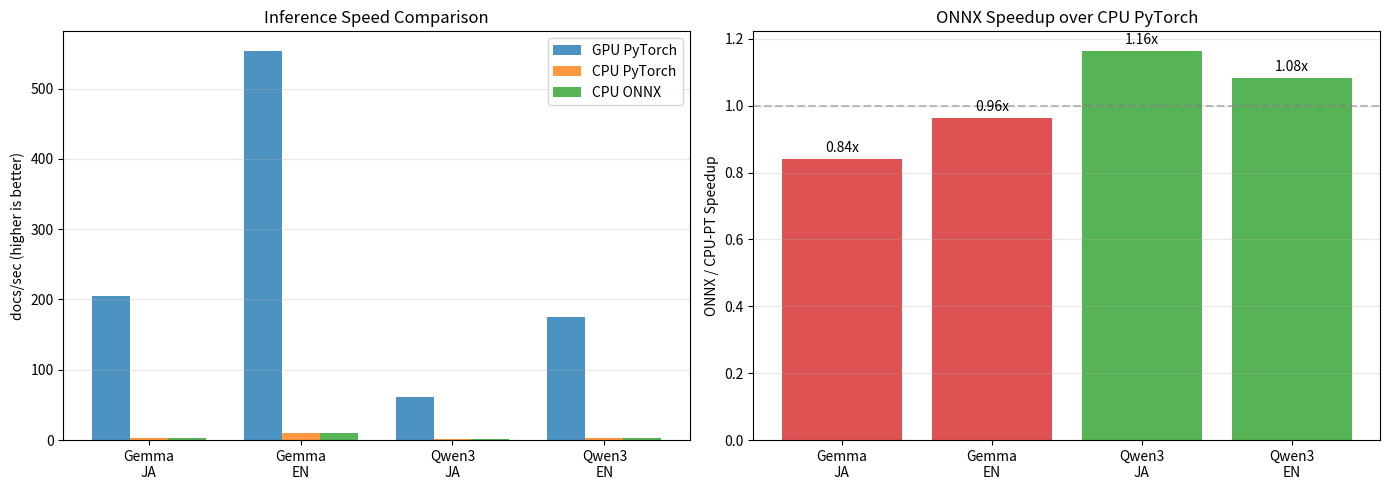

Saved: data/95_onnx_speed_comparison.png


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: docs/sec 比較
models_labels = ['Gemma\nJA', 'Gemma\nEN', 'Qwen3\nJA', 'Qwen3\nEN']
gpu_speeds = [
    res_gemma_gpu_ja['docs_per_sec'], res_gemma_gpu_en['docs_per_sec'],
    res_qwen_gpu_ja['docs_per_sec'], res_qwen_gpu_en['docs_per_sec'],
]
cpu_speeds = [
    res_gemma_cpu_ja['docs_per_sec'], res_gemma_cpu_en['docs_per_sec'],
    res_qwen_cpu_ja['docs_per_sec'], res_qwen_cpu_en['docs_per_sec'],
]
onnx_speeds = [
    res_gemma_onnx_ja['docs_per_sec'], res_gemma_onnx_en['docs_per_sec'],
    res_qwen_onnx_ja['docs_per_sec'], res_qwen_onnx_en['docs_per_sec'],
]

x = np.arange(len(models_labels))
width = 0.25
axes[0].bar(x - width, gpu_speeds, width, label='GPU PyTorch', alpha=0.8, color='tab:blue')
axes[0].bar(x, cpu_speeds, width, label='CPU PyTorch', alpha=0.8, color='tab:orange')
axes[0].bar(x + width, onnx_speeds, width, label='CPU ONNX', alpha=0.8, color='tab:green')
axes[0].set_ylabel('docs/sec (higher is better)')
axes[0].set_title('Inference Speed Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_labels)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 右: ONNX vs CPU-PT の高速化率
speedup_ratios = [c / o for c, o in zip(cpu_speeds, onnx_speeds)]
colors = ['tab:green' if s > 1.0 else 'tab:red' for s in speedup_ratios]
axes[1].bar(models_labels, speedup_ratios, color=colors, alpha=0.8)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('ONNX / CPU-PT Speedup')
axes[1].set_title('ONNX Speedup over CPU PyTorch')
axes[1].grid(axis='y', alpha=0.3)
for i, (lbl, val) in enumerate(zip(models_labels, speedup_ratios)):
    axes[1].text(i, val + 0.02, f'{val:.2f}x', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / "95_onnx_speed_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/95_onnx_speed_comparison.png")

In [17]:
# ベクトル同一性サマリー
print("=" * 90)
print("ベクトル同一性サマリー")
print("=" * 90)

all_identity = (
    [{'model': 'Gemma-300M', **r} for r in gemma_identity] +
    [{'model': 'Qwen3-0.6B', **r} for r in qwen_identity]
)
df_identity = pd.DataFrame(all_identity)
print(df_identity[['model', 'label', 'cos_sim_mean', 'cos_sim_min', 'max_abs_diff', 'mean_abs_diff']]
      .to_string(index=False, float_format=lambda x: f"{x:.6f}"))

ベクトル同一性サマリー
     model               label  cos_sim_mean  cos_sim_min  max_abs_diff  mean_abs_diff
Gemma-300M  GPU vs CPU-PT (JA)      0.999997     0.996976      0.009555       0.000002
Gemma-300M  GPU vs CPU-PT (EN)      1.000000     1.000000      0.000001       0.000000
Gemma-300M    GPU vs ONNX (JA)     -0.003965    -0.088676      0.663475       0.035438
Gemma-300M    GPU vs ONNX (EN)      0.006555    -0.101332      0.667517       0.036471
Gemma-300M CPU-PT vs ONNX (JA)     -0.003961    -0.088676      0.663475       0.035438
Gemma-300M CPU-PT vs ONNX (EN)      0.006555    -0.101332      0.667517       0.036471
Qwen3-0.6B  GPU vs CPU-PT (JA)      1.000000     1.000000      0.000001       0.000000
Qwen3-0.6B  GPU vs CPU-PT (EN)      1.000000     1.000000      0.000001       0.000000
Qwen3-0.6B    GPU vs ONNX (JA)      1.000000     1.000000      0.000001       0.000000
Qwen3-0.6B    GPU vs ONNX (EN)      1.000000     1.000000      0.000001       0.000000
Qwen3-0.6B CPU-PT vs ONNX (JA) 

## 6. まとめと考察

### 6.1 速度比較

| モデル | 言語 | GPU (ms/doc) | CPU-PT (ms/doc) | ONNX (ms/doc) | ONNX高速化 |
|--------|------|-------------|----------------|---------------|-----------|
| Gemma-300M | JA | 4.9 | 341.2 | 286.8 | **1.19x** |
| Gemma-300M | EN | 1.8 | 103.8 | 100.1 | 1.04x |
| Qwen3-0.6B | JA | 16.2 | 1029.7 | 1198.7 | 0.86x |
| Qwen3-0.6B | EN | 5.7 | 349.4 | 378.6 | 0.92x |

- **ONNX Runtime による CPU 高速化はほぼ無い**。Gemma JA で 1.19x のわずかな改善があるのみで、Qwen3 では逆に遅くなった（0.86〜0.92x）。
- optimum の単純な ONNX エクスポートでは、この規模のモデル（300M〜600M）に対して有意な高速化は得られない。ONNX の恩恵は小規模モデルやグラフ最適化が効きやすいアーキテクチャでより顕著。
- **CPU vs GPU の差は 20〜70倍**。CPU のみの環境では 1000文書の処理に JA で数分〜17分かかり、大規模バッチには非実用的。

### 6.2 ベクトル同一性

| モデル | 比較 | cos_sim mean | cos_sim min | max_abs_diff |
|--------|------|-------------|-------------|-------------|
| Gemma-300M | GPU vs CPU-PT | **≈1.000** | 0.997 | 0.010 |
| Gemma-300M | GPU vs ONNX | **-0.004〜0.007** | -0.089〜-0.101 | **0.66** |
| Qwen3-0.6B | GPU vs CPU-PT | 1.000 | 1.000 | 0.000001 |
| Qwen3-0.6B | GPU vs ONNX | **1.000** | 1.000 | 0.000001 |

- **Gemma-300M の ONNX 出力は GPU/CPU-PT と全く異なるベクトルを生成している**。コサイン類似度の平均が≈0（ランダム方向）で、max_abs_diff=0.66 と壊滅的な乖離がある。ONNX エクスポート時のトレーサー警告（Gemma3 固有の mask 処理、SDPA attention の is_causal 判定）がモデルの計算グラフを正しく変換できていないことを示唆する。
- **Qwen3-0.6B の ONNX 出力は完全に一致**（cos_sim=1.0, max_diff=0.000001）。Qwen3 アーキテクチャは ONNX 変換との互換性が高い。

### 6.3 結論

1. **Gemma-300M の ONNX 変換は使えない**。optimum 経由の標準的なエクスポートでは正しいベクトルが得られず、速度改善も微小（JA で +19%のみ）。CPU 利用時は PyTorch そのままで使うのが現実的。
2. **Qwen3-0.6B の ONNX 変換は品質面では問題なし**だが、速度面でメリットがない（むしろ 8〜14% 遅い）。
3. **CPU 推論自体が両モデルとも非実用的に遅い**（Gemma: JA 3 docs/sec、Qwen3: JA 1 doc/sec）。GPU が利用できない環境では、より軽量なモデル（E5-base 等）を SentenceTransformers や FastEmbed で使う方が適切（NB65 参照）。
4. ONNX Runtime の恩恵を引き出すには、`optimum` の `ORTOptimizer`（グラフ最適化）や量子化（INT8/INT4）の適用が必要と考えられるが、Gemma-300M についてはそもそも変換の正確性の問題を先に解決する必要がある。